# Peramalan Kadar NO₂ di Kabupaten Sumenep, Madura.

Nitrogen Dioksida (NO₂) merupakan salah satu polutan udara yang dapat memengaruhi kualitas lingkungan dan kesehatan manusia. Gas ini umumnya berasal dari aktivitas pembakaran bahan bakar seperti kendaraan bermotor, industri, dan aktivitas transportasi. Oleh karena itu, pemantauan kadar NO₂ penting dilakukan untuk mengetahui kondisi kualitas udara suatu wilayah.

Pada tugas ini dilakukan pengambilan dan analisis data NO₂ di Kabupaten Sumenep menggunakan data satelit Sentinel-5P. Data yang diperoleh akan diolah menjadi data time series untuk mengetahui pola perubahan kadar NO₂ serta digunakan dalam proses peramalan guna memperkirakan kondisi kualitas udara pada periode berikutnya.

## 1. Pengumpulan Data

Pertama kita akan mengumpulkan data Time Series harian kadar NO₂ di daerah Kabupaten Sumenep. Pengumpulan data dilakukan dari sumber website https://dataspace.copernicus.eu/. Sebelum melakukan pengambilan data, buat akun terlebih dahulu pada website Copernicus Data Space Ecosystem.

Dokumentasi cara pengambilan data dapat dilihat pada:
https://documentation.dataspace.copernicus.eu/notebook-samples/openeo/NO2Covid.html

Untuk menuliskan kode Python dalam proses pengambilan data, silakan kunjungi halaman:
https://dataspace.copernicus.eu/analyse/jupyterlab



In [2]:
# nstall OpenEO:
!pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.5/345.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [3]:
# Import library:
import openeo

In [4]:
# Login ke Copernicus:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=HWBH-WNQH 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


In [13]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [113.5888616005364, -6.918612908801933],
            [114.13101331376612, -6.918483397429483],
            [114.13101331376612, -7.156681989885726],
            [113.58860352737378, -7.156677848626558],
            [113.5888616005364, -6.918612908801933]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2024-01-01", "2024-08-30"],
    spatial_extent={
        "west": 113.58860352737378,
        "south": -7.156681989885726,
        "east": 114.13101331376612,
        "north": -6.918483397429483
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

Kode di atas digunakan untuk mengambil data NO₂ pada wilayah Kabupaten Sumenep menggunakan data satelit Sentinel-5P. Data kemudian dirata-ratakan secara harian dan spasial sehingga menghasilkan data time series kadar NO₂ wilayah Sumenep.

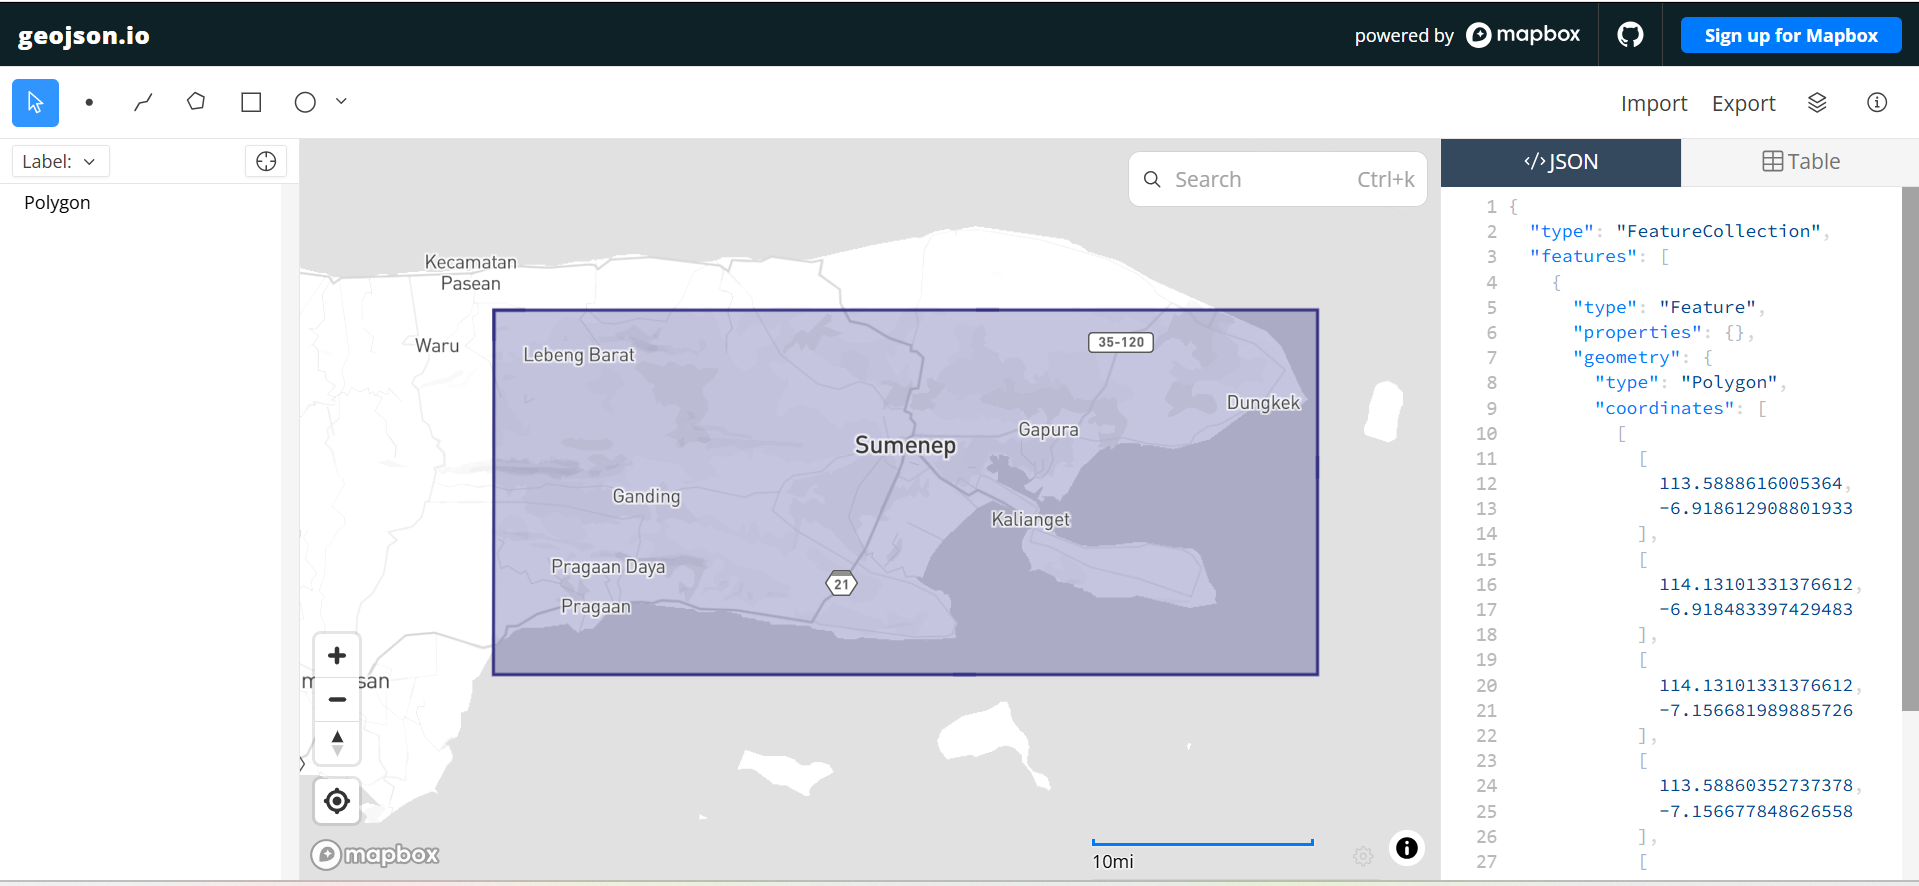

Gambar di atas menunjukkan wilayah Kabupaten Sumenep yang digunakan sebagai Area of Interest (AOI) dalam pengambilan data NO₂. Koordinat hasil GeoJSON.io digunakan sebagai batas area penelitian.

In [15]:
job = s5p_no2_daily.execute_batch(
    title="NO2 in Sumenep",
    outputfile="NO2Sumenep.nc"
)

0:00:00 Job 'j-26060308202642f294877d743a5e6738': send 'start'
0:00:22 Job 'j-26060308202642f294877d743a5e6738': queued (progress 0%)
0:00:27 Job 'j-26060308202642f294877d743a5e6738': queued (progress 0%)
0:00:34 Job 'j-26060308202642f294877d743a5e6738': queued (progress 0%)
0:00:42 Job 'j-26060308202642f294877d743a5e6738': queued (progress 0%)
0:00:52 Job 'j-26060308202642f294877d743a5e6738': running (progress N/A)
0:01:04 Job 'j-26060308202642f294877d743a5e6738': running (progress N/A)
0:01:20 Job 'j-26060308202642f294877d743a5e6738': running (progress N/A)
0:01:39 Job 'j-26060308202642f294877d743a5e6738': running (progress N/A)
0:02:03 Job 'j-26060308202642f294877d743a5e6738': running (progress N/A)
0:02:33 Job 'j-26060308202642f294877d743a5e6738': running (progress N/A)
0:03:11 Job 'j-26060308202642f294877d743a5e6738': running (progress N/A)
0:03:58 Job 'j-26060308202642f294877d743a5e6738': finished (progress 100%)


Setelah proses agregasi selesai, data dieksekusi menggunakan execute_batch() untuk memulai proses pengambilan data NO₂. Hasil pengolahan kemudian disimpan dalam file NO2Sumenep.nc yang nantinya digunakan untuk tahap analisis selanjutnya.

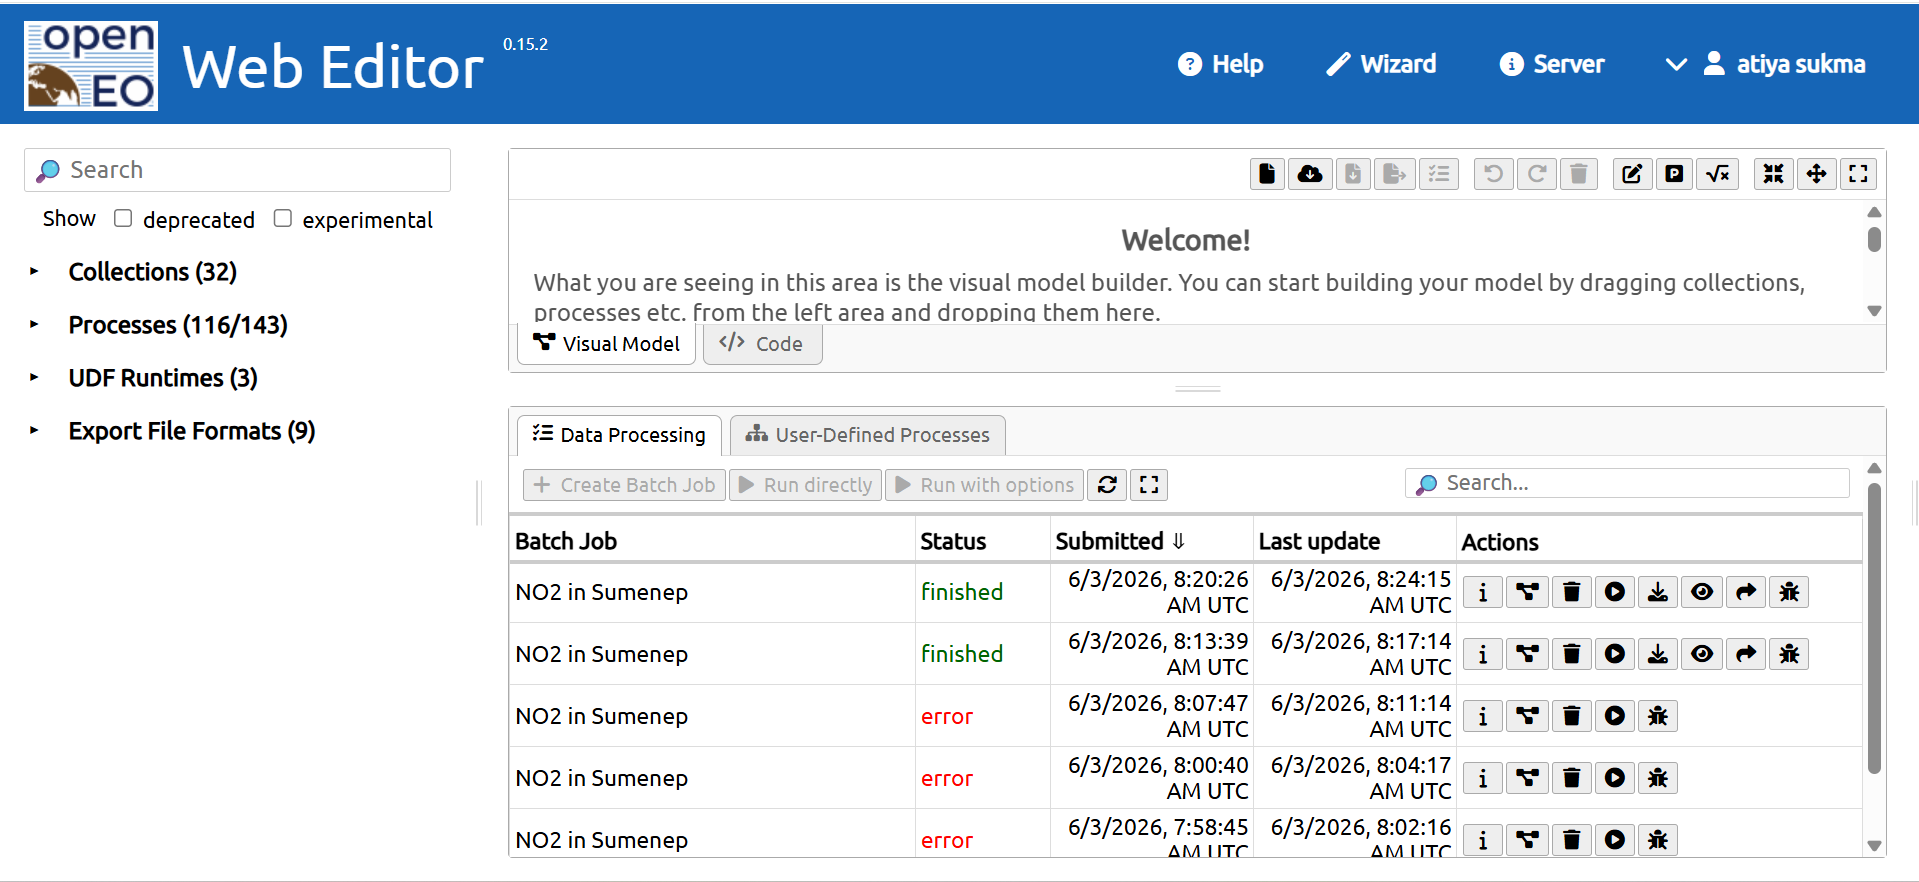

Gambar di atas menunjukkan halaman OpenEO Web Editor yang digunakan untuk memantau proses pengolahan data NO₂. Melalui halaman ini, pengguna dapat melihat status job yang telah dijalankan, mulai dari proses antrean (queued), pemrosesan (running), hingga selesai (finished).

In [17]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.6 MB/s eta 0:00:00


In [21]:
import netCDF4

# Baca file hasil download
file_path = "NO2Sumenep.nc"
ds = netCDF4.Dataset(file_path)

# Lihat seluruh variabel yang tersedia
print("📦 Variabel dalam file:")
print(ds.variables.keys())

# Ambil NO2
no2 = ds.variables["NO2"][:]

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal jika punya atribut 'units'
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback kalau tidak ada units

# Tampilkan struktur data NO2
print(type(no2))
# type <class 'numpy.ma.core.MaskedArray'>

print(len(no2))
# banyaknya data record NO2

print(len(no2[0]))
# panjang data per baris

print(len(no2[0][0]))
# panjang data per kolom

print(no2[0][0][0])
# contoh nilai NO2 pertama

# Tampilkan beberapa tanggal pertama
print("\nContoh tanggal:")
print(dates[:5])

# Tutup file
ds.close()

📦 Variabel dalam file:
dict_keys(['t', 'x', 'y', 'crs', 'NO2'])
<class 'numpy.ma.MaskedArray'>
236
7
10
--

Contoh tanggal:
[cftime.DatetimeGregorian(2024, 1, 2, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2024, 1, 3, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2024, 1, 4, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2024, 1, 5, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2024, 1, 6, 0, 0, 0, 0, has_year_zero=False)]


Kode di atas digunakan untuk membaca file NO2Sumenep.nc, mengambil variabel NO₂ dan waktu, kemudian menampilkan struktur data yang tersimpan pada file NetCDF. Informasi ini digunakan untuk mengetahui bentuk data sebelum dilakukan proses preprocessing dan analisis lebih lanjut.

In [22]:
print(len(no2))
print(len(no2[0]))
print(len(no2[0][0]))

236
7
10


In [23]:
print("Contoh data pertama:")
for i in range(0, 10):
    print(no2[i])

Contoh data pertama:
[[-- -- -- -- -- -- 2.2427660951507278e-05 2.2427660951507278e-05
  2.2427660951507278e-05 2.0416562620084733e-05]
 [-- -- -- -- -- -- -- 1.9728109691641293e-05 1.9728109691641293e-05
  2.0416562620084733e-05]
 [-- -- -- -- -- 3.786855131693301e-06 3.786855131693301e-06
  1.1073316272813827e-05 1.1073316272813827e-05 1.5139777133299503e-05]
 [-- -- -- 8.77264540122269e-07 8.77264540122269e-07
  3.786855131693301e-06 3.786855131693301e-06 1.1073316272813827e-05
  1.9159680960001424e-05 1.689929558779113e-05]
 [-- -- 6.46165972284507e-06 2.409591070318129e-05 2.409591070318129e-05
  1.9163166143698618e-05 1.9163166143698618e-05 1.9159680960001424e-05
  1.9159680960001424e-05 1.689929558779113e-05]
 [-- 6.46165972284507e-06 6.46165972284507e-06 2.409591070318129e-05
  2.409591070318129e-05 1.2659648746193852e-05 1.2659648746193852e-05
  1.678084117884282e-05 1.678084117884282e-05 1.880515083030332e-05]
 [-- 1.982180583581794e-05 1.982180583581794e-05 1.134056492446689

Untuk mengetahui struktur data NO₂, dilakukan pengecekan jumlah data berdasarkan panjang array. Setelah itu ditampilkan 10 data pertama untuk melihat bentuk data awal. Dari hasil tersebut terlihat bahwa dalam satu hari terdapat beberapa nilai NO₂, sehingga data perlu dirata-ratakan agar setiap tanggal hanya memiliki satu nilai. Selain itu, terdapat kemungkinan missing value yang perlu ditangani pada tahap preprocessing.

### a. Mengatasi Missing Value menggunakan metode Interpolasi Linear

In [24]:
import numpy as np
import pandas as pd

# Interpolasi Linear
no2_filled = np.zeros_like(no2)

no2_filled = no2.filled(0)

# Loop tiap grid (y, x)
for i in range(no2.shape[1]):
    for j in range(no2.shape[2]):
        series = pd.Series(no2[:, i, j])
        no2_filled[:, i, j] = series.interpolate(
            method="linear",
            limit_direction="both"
        ).to_numpy()

Kode di atas digunakan untuk mengatasi missing value pada data NO₂ Kabupaten Sumenep. Nilai yang kosong diisi menggunakan metode interpolasi linear agar data dapat digunakan pada proses analisis berikutnya.

### b. Rata-rata kan Data dan ubah Datetime

In [25]:
new_dates = []
new_no2 = []

for i in range(len(dates)):
    # Ubah format datetime
    new_date = dates[i].strftime("%Y-%m-%d")
    new_dates.append(new_date)

    # Rata-ratakan data NO2 harian
    new_no2.append(np.mean(no2_filled[i]))

Kode tersebut digunakan untuk mengubah format waktu menjadi tanggal dan menghitung rata-rata kadar NO₂ harian. Hasilnya berupa satu nilai NO₂ untuk setiap tanggal pada wilayah Kabupaten Sumenep.

### c. Simpan data dalam bentuk CSV

In [26]:
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV
df.to_csv("NO2_Sumenep_timeseries.csv", index=False)

etelah proses interpolasi dan perhitungan rata-rata harian selesai, data disimpan dalam format CSV agar lebih mudah digunakan pada tahap analisis dan pemodelan selanjutnya.

### d. Pengecekan Missing Value Data Harian pada CSV

In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv("NO2_Sumenep_timeseries.csv")

# Pastikan kolom 'date' bertipe datetime
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2023-10-01"
end_date = "2025-09-30"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 495
Daftar tanggal missing:
DatetimeIndex(['2023-10-01', '2023-10-02', '2023-10-03', '2023-10-04',
               '2023-10-05', '2023-10-06', '2023-10-07', '2023-10-08',
               '2023-10-09', '2023-10-10',
               ...
               '2025-09-21', '2025-09-22', '2025-09-23', '2025-09-24',
               '2025-09-25', '2025-09-26', '2025-09-27', '2025-09-28',
               '2025-09-29', '2025-09-30'],
              dtype='datetime64[ns]', length=495, freq=None)


Kode di atas digunakan untuk memeriksa apakah terdapat tanggal yang hilang pada data time series NO₂ Kabupaten Sumenep. Pemeriksaan dilakukan dengan membandingkan tanggal yang tersedia pada dataset dengan rentang tanggal yang seharusnya ada. Jika ditemukan tanggal yang hilang, maka perlu dilakukan penanganan missing value sebelum tahap analisis lebih lanjut.

In [28]:
import pandas as pd

# Pastikan datetime dan sorting
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

# Buat rentang tanggal lengkap
full_range = pd.date_range(start="2023-10-01", end="2025-09-30", freq='D')

# Reindex agar tanggal yang hilang muncul sebagai NaN
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Interpolasi linear berdasarkan indeks waktu
df['NO2'] = df['NO2'].interpolate(method='time')

# Isi nilai kosong di awal/akhir jika masih ada
df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')

# Simpan kembali ke CSV
df.to_csv("NO2_Sumenep_timeseries_interpolated.csv")

/tmp/ipykernel_3116/1910853175.py:18: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['NO2'] = df['NO2'].fillna(method='bfill').fillna(method='ffill')


Setelah dilakukan pengecekan dan interpolasi, data NO₂ Kabupaten Sumenep sudah tidak memiliki missing value. Dataset akhir terdiri dari dua kolom, yaitu date sebagai tanggal dan NO2 sebagai nilai rata-rata kadar NO₂ harian.

### e. Deteksi Outlier IQR

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_Sumenep_timeseries_interpolated.csv")

df['date'] = pd.to_datetime(df['date'])

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[
    (df['NO2'] < lower_bound) |
    (df['NO2'] > upper_bound)
]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 114
          date       NO2
95  2024-01-04  0.000012
101 2024-01-10  0.000021
102 2024-01-11  0.000021
103 2024-01-12  0.000025
141 2024-02-19  0.000010


Kode di atas digunakan untuk mendeteksi data outlier pada time series NO₂ Kabupaten Sumenep menggunakan metode Interquartile Range (IQR). Data yang berada di luar batas bawah (lower bound) dan batas atas (upper bound) akan dikategorikan sebagai outlier.

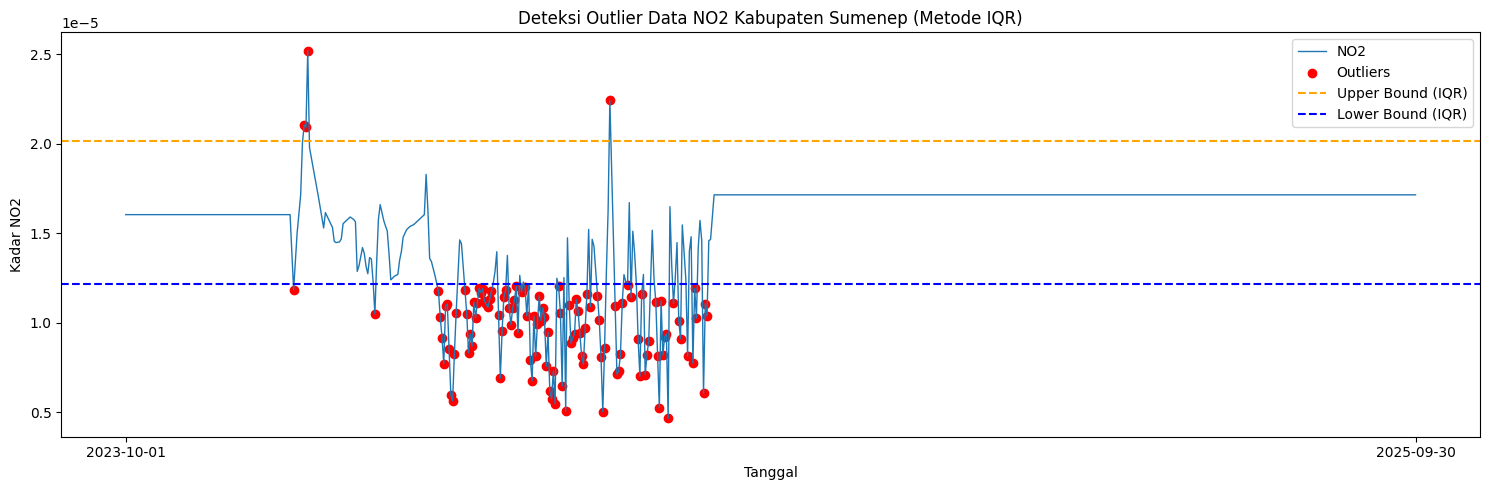

In [30]:
# === Visualisasi ===
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

# Titik Outlier
plt.scatter(
    outliers_iqr['date'],
    outliers_iqr['NO2'],
    color='red',
    marker='o',
    label='Outliers'
)

# Garis batas atas & bawah
plt.axhline(
    upper_bound,
    color='orange',
    linestyle='dashed',
    label='Upper Bound (IQR)'
)

plt.axhline(
    lower_bound,
    color='blue',
    linestyle='dashed',
    label='Lower Bound (IQR)'
)

plt.title("Deteksi Outlier Data NO2 Kabupaten Sumenep (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()

plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[
        df['date'].iloc[0].strftime('%Y-%m-%d'),
        df['date'].iloc[-1].strftime('%Y-%m-%d')
    ]
)

plt.show()

Gambar menunjukkan hasil deteksi outlier pada data NO₂ Kabupaten Sumenep menggunakan metode Interquartile Range (IQR). Titik berwarna merah merupakan data yang berada di luar batas bawah (lower bound) dan batas atas (upper bound) sehingga dikategorikan sebagai outlier. Hasil deteksi menunjukkan bahwa terdapat beberapa nilai ekstrem yang perlu ditangani sebelum dilakukan proses pemodelan agar tidak memengaruhi performa model prediksi.

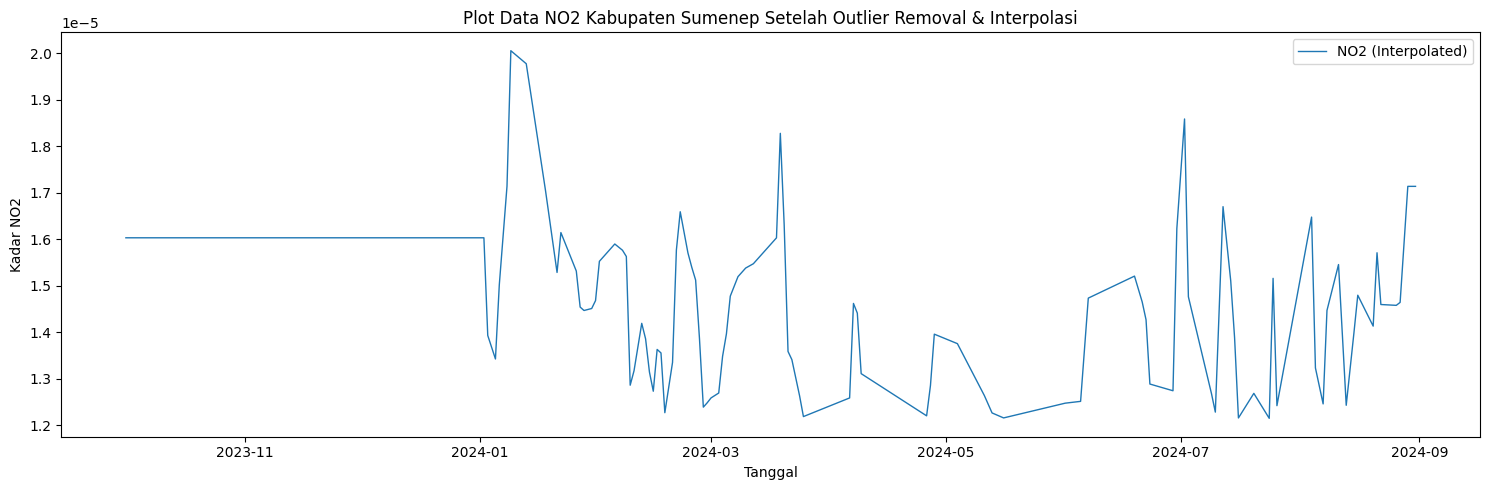

In [40]:
df_fixed = df[df['date'] < "2024-09-01"].copy()

plt.figure(figsize=(15,5))
plt.plot(df_fixed['date'], df_fixed['NO2_filled'], label="NO2 (Interpolated)", linewidth=1)

plt.title("Plot Data NO2 Kabupaten Sumenep Setelah Outlier Removal & Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

Data setelah September 2024 tidak digunakan karena nilainya konstan akibat proses pengisian nilai kosong. Oleh karena itu, data dipotong sampai periode yang masih memiliki variasi agar hasil analisis time series lebih representatif.

## 3. Modeling menggunakan KNN Regression
Pada tahap ini, data time series kadar NO₂ harian Kabupaten Sumenep digunakan untuk membangun model prediksi menggunakan metode KNN Regression. Data akan diubah menjadi bentuk supervised learning dengan menggunakan data beberapa hari sebelumnya sebagai fitur dan data hari ini sebagai target.

### a. Uji Korelasi Data


In [41]:
import pandas as pd

def create_supervised(data, n_lag=30):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-4 sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari ini
    df_supervised['NO2(t)'] = data

    # Hapus baris yang masih mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# Contoh penggunaan
supervised_df30 = create_supervised(df['NO2_filled'], n_lag=30)

# Ambil semua lag dan kolom target
lag_cols = supervised_df30.drop(columns='NO2(t)').columns
correlations = supervised_df30[lag_cols].corrwith(supervised_df30['NO2(t)'])

# Tampilkan nilai korelasi
print(correlations)

NO2(t-30)    0.644906
NO2(t-29)    0.655611
NO2(t-28)    0.667681
NO2(t-27)    0.678685
NO2(t-26)    0.683283
NO2(t-25)    0.696453
NO2(t-24)    0.708935
NO2(t-23)    0.724615
NO2(t-22)    0.728675
NO2(t-21)    0.729981
NO2(t-20)    0.727056
NO2(t-19)    0.718611
NO2(t-18)    0.709733
NO2(t-17)    0.704170
NO2(t-16)    0.699750
NO2(t-15)    0.704395
NO2(t-14)    0.716819
NO2(t-13)    0.729740
NO2(t-12)    0.736760
NO2(t-11)    0.741650
NO2(t-10)    0.746598
NO2(t-9)     0.741523
NO2(t-8)     0.745423
NO2(t-7)     0.757755
NO2(t-6)     0.774942
NO2(t-5)     0.798353
NO2(t-4)     0.825795
NO2(t-3)     0.860491
NO2(t-2)     0.908484
NO2(t-1)     0.959321
dtype: float64


Berdasarkan hasil uji korelasi, nilai NO₂ pada beberapa hari sebelumnya memiliki hubungan yang kuat terhadap nilai NO₂ hari ini. Korelasi tertinggi terdapat pada lag t-1, yaitu sebesar 0.959321. Oleh karena itu, fitur lag terdekat seperti t-1 sampai t-4 dapat digunakan dalam proses pemodelan KNN Regression.

### b. Normalisasi Data


In [42]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()

df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])

print(df[['date', 'NO2_filled', 'NO2_scaled']].head())
print(df.info())

        date  NO2_filled  NO2_scaled
0 2023-10-01    0.000016    0.491123
1 2023-10-02    0.000016    0.491123
2 2023-10-03    0.000016    0.491123
3 2023-10-04    0.000016    0.491123
4 2023-10-05    0.000016    0.491123
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         731 non-null    datetime64[ns]
 1   NO2          731 non-null    float64       
 2   NO2_cleaned  617 non-null    float64       
 3   NO2_filled   731 non-null    float64       
 4   NO2_scaled   731 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 28.7 KB
None


Normalisasi data dilakukan menggunakan metode Min-Max Scaling. Proses ini mengubah rentang nilai NO₂ menjadi skala 0–1 sehingga perbedaan skala data tidak memengaruhi proses perhitungan jarak pada algoritma KNN Regression.

### c.Mengubah Data


In [43]:
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)

print(supervised_df)
print(supervised_df.shape)

     NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4    0.491123  0.491123  0.491123  0.491123  0.491123
5    0.491123  0.491123  0.491123  0.491123  0.491123
6    0.491123  0.491123  0.491123  0.491123  0.491123
7    0.491123  0.491123  0.491123  0.491123  0.491123
8    0.491123  0.491123  0.491123  0.491123  0.491123
..        ...       ...       ...       ...       ...
726  0.631030  0.631030  0.631030  0.631030  0.631030
727  0.631030  0.631030  0.631030  0.631030  0.631030
728  0.631030  0.631030  0.631030  0.631030  0.631030
729  0.631030  0.631030  0.631030  0.631030  0.631030
730  0.631030  0.631030  0.631030  0.631030  0.631030

[727 rows x 5 columns]
(727, 5)


In [44]:
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)

print(supervised_df10)
print(supervised_df10.shape)

     NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10    0.491123  0.491123  0.491123  0.491123  0.491123  0.491123  0.491123   
11    0.491123  0.491123  0.491123  0.491123  0.491123  0.491123  0.491123   
12    0.491123  0.491123  0.491123  0.491123  0.491123  0.491123  0.491123   
13    0.491123  0.491123  0.491123  0.491123  0.491123  0.491123  0.491123   
14    0.491123  0.491123  0.491123  0.491123  0.491123  0.491123  0.491123   
..         ...       ...       ...       ...       ...       ...       ...   
726   0.631030  0.631030  0.631030  0.631030  0.631030  0.631030  0.631030   
727   0.631030  0.631030  0.631030  0.631030  0.631030  0.631030  0.631030   
728   0.631030  0.631030  0.631030  0.631030  0.631030  0.631030  0.631030   
729   0.631030  0.631030  0.631030  0.631030  0.631030  0.631030  0.631030   
730   0.631030  0.631030  0.631030  0.631030  0.631030  0.631030  0.631030   

     NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10   0.491123  0.

Selain menggunakan 4 hari sebelumnya, data juga dibentuk menggunakan 10 hari sebelumnya sebagai perbandingan. Hal ini dilakukan untuk mengetahui apakah penggunaan jumlah fitur lag yang lebih banyak dapat meningkatkan performa model KNN Regression atau tidak.

### d. Modeling dan Evaluation

In [50]:
# Pakai data yang sudah dipotong agar tidak ada data datar panjang
df = df_fixed.copy()

# Normalisasi ulang
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])

# Fungsi membuat supervised data
import pandas as pd

def create_supervised(data, n_lag=30):
    df_supervised = pd.DataFrame()

    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    df_supervised['NO2(t)'] = data
    df_supervised.dropna(inplace=True)

    return df_supervised

# Buat data supervised
supervised_df = create_supervised(df['NO2_scaled'], n_lag=4)
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)
supervised_df30 = create_supervised(df['NO2_scaled'], n_lag=30)

print(supervised_df.shape)
print(supervised_df10.shape)
print(supervised_df30.shape)

# Modeling KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def MAPE(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    nonzero = y_true != 0
    return np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100

def train_knn(df_supervised, model_name=""):
    X = df_supervised.drop(columns='NO2(t)').values
    y = df_supervised['NO2(t)'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = MAPE(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size: {len(X_train)} - Test Size: {len(X_test)}")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%")

    return knn, y_test, y_pred

# Jalankan model
knn_4, y_test_4, y_pred_4 = train_knn(supervised_df, "KNN - 4 Hari Sebelumnya")
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")
knn_30, y_test_30, y_pred_30 = train_knn(supervised_df30, "KNN - 30 Hari Sebelumnya")

(332, 5)
(326, 11)
(306, 31)

=== KNN - 4 Hari Sebelumnya ===
Train Size: 265 - Test Size: 67
RMSE: 0.151909
R² Score: 0.3726
MAPE: 353.1412%

=== KNN - 10 Hari Sebelumnya ===
Train Size: 260 - Test Size: 66
RMSE: 0.170530
R² Score: 0.2106
MAPE: 674.1166%

=== KNN - 30 Hari Sebelumnya ===
Train Size: 244 - Test Size: 62
RMSE: 0.193987
R² Score: -0.0320
MAPE: 671.8997%


Berdasarkan hasil evaluasi, model KNN dengan fitur 4 hari sebelumnya menghasilkan performa terbaik dibandingkan penggunaan 10 hari dan 30 hari sebelumnya. Hal ini ditunjukkan oleh nilai RMSE yang paling kecil dan R² Score yang paling tinggi. Dengan demikian, penggunaan data NO₂ 4 hari sebelumnya lebih sesuai untuk memprediksi kadar NO₂ harian Kabupaten Sumenep.

### e. Plotting


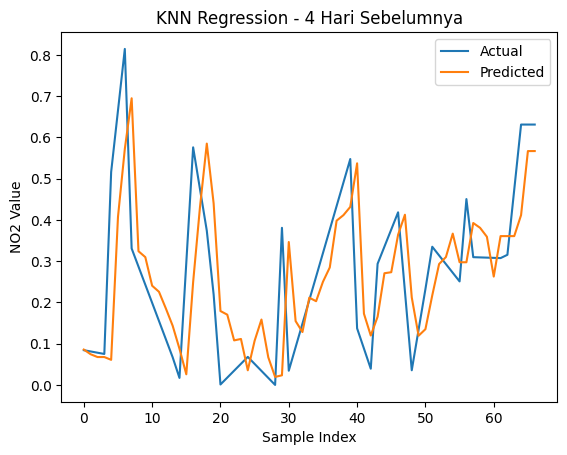

In [51]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.plot(np.arange(len(y_test_4)), y_test_4, label="Actual")
plt.plot(np.arange(len(y_pred_4)), y_pred_4, label="Predicted")
plt.title("KNN Regression - 4 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()
plt.show()

Grafik di atas menunjukkan perbandingan antara data aktual dan hasil prediksi model KNN Regression menggunakan 4 hari sebelumnya sebagai fitur. Garis aktual dan prediksi digunakan untuk melihat seberapa baik model mengikuti pola data NO₂ Kabupaten Sumenep.

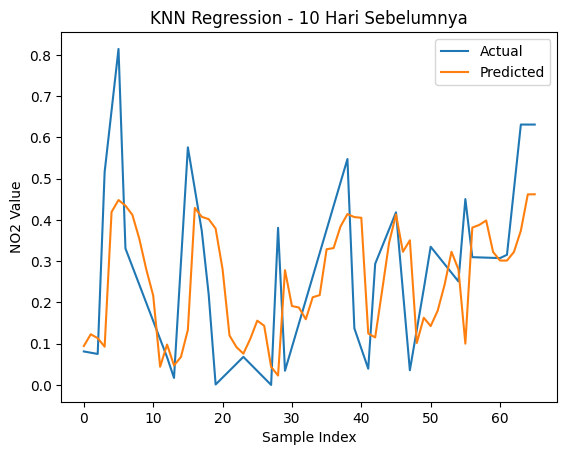

In [52]:
plt.figure()

plt.plot(np.arange(len(y_test_10)), y_test_10, label="Actual")
plt.plot(np.arange(len(y_pred_10)), y_pred_10, label="Predicted")

plt.title("KNN Regression - 10 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()

plt.show()

Grafik menunjukkan bahwa hasil prediksi mengikuti pola data aktual, tetapi masih terdapat selisih pada beberapa titik ekstrem. Oleh karena itu, model KNN dengan 10 hari sebelumnya memiliki kemampuan prediksi yang cukup baik namun belum optimal.

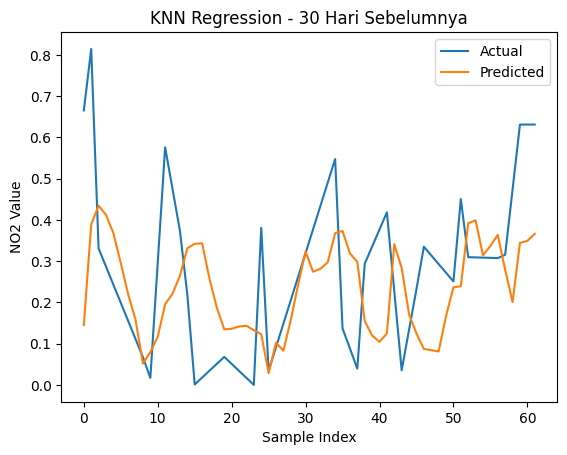

In [53]:
plt.figure()

plt.plot(np.arange(len(y_test_30)), y_test_30, label="Actual")
plt.plot(np.arange(len(y_pred_30)), y_pred_30, label="Predicted")

plt.title("KNN Regression - 30 Hari Sebelumnya")
plt.xlabel("Sample Index")
plt.ylabel("NO2 Value")
plt.legend()

plt.show()

Berdasarkan hasil visualisasi, model KNN Regression dengan 30 hari sebelumnya memiliki kemampuan prediksi yang lebih rendah dibandingkan model 4 hari dan 10 hari sebelumnya. Hal ini ditunjukkan oleh perbedaan yang cukup besar antara nilai aktual dan nilai prediksi pada beberapa titik pengamatan. Oleh karena itu, penggunaan 30 hari sebelumnya sebagai fitur prediksi kurang optimal untuk memodelkan data NO₂ Kabupaten Sumenep.

Berdasarkan hasil evaluasi dan visualisasi, model KNN Regression dengan 4 hari sebelumnya memberikan performa terbaik dengan nilai RMSE paling rendah dan nilai R² tertinggi. Model 10 hari sebelumnya masih mampu mengikuti pola data dengan cukup baik, sedangkan model 30 hari sebelumnya menunjukkan performa paling rendah. Dengan demikian, model KNN Regression menggunakan 4 hari sebelumnya dipilih sebagai model terbaik untuk prediksi kadar NO₂ Kabupaten Sumenep.